In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm

def getOpticalFlow(video):
    """Calculate dense optical flow of input video
    Args:
        video: the input video with shape of [frames,height,width,channel]. dtype=np.array
    Returns:
        flows_x: the optical flow at x-axis, with the shape of [frames,height,width,channel]
        flows_y: the optical flow at y-axis, with the shape of [frames,height,width,channel]
    """
    # initialize the list of optical flows
    gray_video = []
    for i in range(len(video)):
        img = cv2.cvtColor(video[i], cv2.COLOR_RGB2GRAY)
        gray_video.append(np.reshape(img, (224, 224, 1)))

    flows = []
    for i in range(0, len(video) - 1):
        # calculate optical flow between each pair of frames
        flow = cv2.calcOpticalFlowFarneback(
            gray_video[i],
            gray_video[i + 1],
            None,
            0.5,
            3,
            15,
            3,
            5,
            1.2,
            cv2.OPTFLOW_FARNEBACK_GAUSSIAN,
        )
        # subtract the mean in order to eliminate the movement of camera
        flow[..., 0] -= np.mean(flow[..., 0])
        flow[..., 1] -= np.mean(flow[..., 1])
        # normalize each component in optical flow
        flow[..., 0] = cv2.normalize(flow[..., 0], None, 0, 255, cv2.NORM_MINMAX)
        flow[..., 1] = cv2.normalize(flow[..., 1], None, 0, 255, cv2.NORM_MINMAX)
        # Add into list
        flows.append(flow)

    # Padding the last frame as empty array
    flows.append(np.zeros((224, 224, 2)))

    return np.array(flows, dtype=np.float32)

def Video2Npy(file_path, resize=(224, 224)):
    """Load video and tansfer it into .npy format
    Args:
        file_path: the path of video file
        resize: the target resolution of output video
    Returns:
        frames: gray-scale video
        flows: magnitude video of optical flows
    """
    # Load video
    cap = cv2.VideoCapture(file_path)
    # Get number of frames
    len_frames = int(cap.get(7))
    # Extract frames from video
    try:
        frames = []
        for i in range(len_frames - 1):
            _, frame = cap.read()
            frame = cv2.resize(frame, resize, interpolation=cv2.INTER_AREA)
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = np.reshape(frame, (224, 224, 3))
            frames.append(frame)
    except:
        print("Error: ", file_path, len_frames, i)
    finally:
        frames = np.array(frames)
        cap.release()

    # Get the optical flow of video
    flows = getOpticalFlow(frames)

    result = np.zeros((len(flows), 224, 224, 5))
    result[..., :3] = frames
    result[..., 3:] = flows

    return result

def Save2Npy(file_dir, save_dir):
    """Transfer all the videos and save them into specified directory
    Args:
        file_dir: source folder of target videos
        save_dir: destination folder of output .npy files
    """
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    # List the files
    videos = os.listdir(file_dir)
    for v in tqdm(videos):
        # Split video name
        video_name = v.split(".")[0]
        # Get src
        video_path = os.path.join(file_dir, v)
        # Get dest
        save_path = os.path.join(save_dir, video_name + ".npy")
        # Load and preprocess video
        data = Video2Npy(file_path=video_path, resize=(224, 224))
        data = np.uint8(data)
        # Save as .npy file
        np.save(save_path, data)

    return None

# TODO Here
- replace the source_path to the path of original dataset
- replace the target_path to where you want to save transformed data

In [16]:
source_path = "RWF-2000"
target_path = "rwf2000_Npy"

for f1 in ["val"]:
    for f2 in ["Fight", "NonFight"]:
        path1 = os.path.join(source_path, f1, f2)
        path2 = os.path.join(target_path, f1, f2)
        Save2Npy(file_dir=path1, save_dir=path2)


100%|██████████| 200/200 [10:09<00:00,  3.05s/it]


In [ ]:
import os
import numpy as np
from keras.models import load_model
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from keras.optimizers import SGD


sgd = SGD(lr=0.01, decay=1e-6, momentum=0.9, nesterov=True)

model = load_model("../Models/keras_model.h5", compile=False)

model.compile(optimizer=sgd, loss="categorical_crossentropy", metrics=["accuracy"])



expected_frames = model.input_shape[1]  # e.g. 20 or 32

val_dir = "rwf2000_Npy/val"
classes = ["NonFight", "Fight"]  # order must match training
y_true, y_pred = [], []

for label_idx, label_name in enumerate(classes):
    folder = os.path.join(val_dir, label_name)
    for file in os.listdir(folder):
        if file.endswith(".npy"):
            video_path = os.path.join(folder, file)
            video = np.load(video_path)

            # add batch dimension
            video = np.expand_dims(video, axis=0)

            # pad or trim frames
            if video.shape[1] > expected_frames:
                video = video[:, :expected_frames]
            elif video.shape[1] < expected_frames:
                pad_count = expected_frames - video.shape[1]
                shape_to_pad = (1, pad_count, 224, 224, 5)
                video = np.concatenate(
                    [video, np.zeros(shape_to_pad, dtype=video.dtype)], axis=1
                )

            # predict
            pred = model.predict(video, verbose=0)
            y_true.append(label_idx)
            y_pred.append(np.argmax(pred))

# ---- Evaluation ----
acc = accuracy_score(y_true, y_pred)
print(f"\nValidation Accuracy: {acc:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=classes))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Accuracy plot
plt.bar(["Accuracy"], [acc])
plt.ylim(0, 1)
plt.title("Validation Accuracy")
plt.show()


                                   Video Path  Ground Truth  Prediction
0     rwf2000_Npy/val\NonFight\10uSOcwS_0.npy             0           1
1     rwf2000_Npy/val\NonFight\1AURh0Wj_0.npy             0           0
2  rwf2000_Npy/val\NonFight\1MVS2QPWbHc_0.npy             0           0
3  rwf2000_Npy/val\NonFight\1MVS2QPWbHc_1.npy             0           0
4  rwf2000_Npy/val\NonFight\1W8hsVvyKt4_0.npy             0           0

Validation Accuracy: 0.3600

Classification Report:
              precision    recall  f1-score   support

    NonFight       0.42      0.70      0.52       200
       Fight       0.06      0.02      0.03       200

    accuracy                           0.36       400
   macro avg       0.24      0.36      0.28       400
weighted avg       0.24      0.36      0.28       400



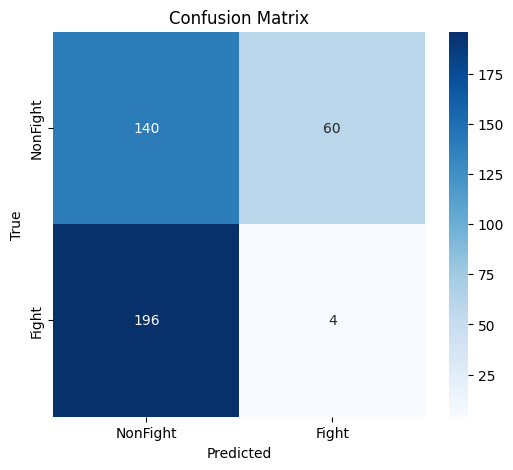

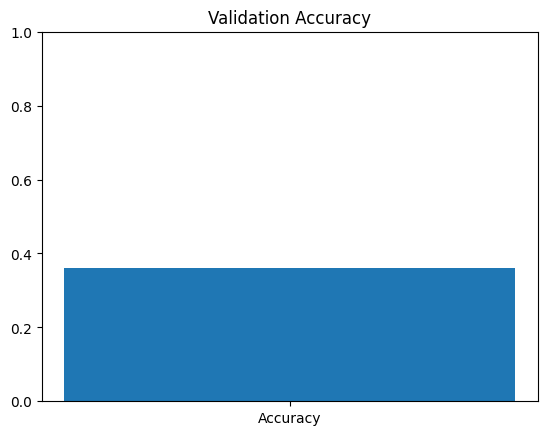

In [17]:
import os
import numpy as np
import pandas as pd
from keras.models import load_model
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from keras.optimizers import SGD

# ---- Load model ----
sgd = SGD(lr=0.01, decay=1e-6, momentum=0.9, nesterov=True)
model = load_model("../Models/keras_model.h5", compile=False)
model.compile(optimizer=sgd, loss="categorical_crossentropy", metrics=["accuracy"])

expected_frames = model.input_shape[1]  # e.g. 20 or 32

val_dir = "rwf2000_Npy/val"
classes = ["NonFight", "Fight"]  # order must match training
y_true, y_pred = [], []
rows = []  # for table

# ---- Iterate over validation set ----
for label_idx, label_name in enumerate(classes):
    folder = os.path.join(val_dir, label_name)
    for file in os.listdir(folder):
        if file.endswith(".npy"):
            video_path = os.path.join(folder, file)
            video = np.load(video_path)

            # add batch dimension
            video = np.expand_dims(video, axis=0)

            # pad or trim frames
            if video.shape[1] > expected_frames:
                video = video[:, :expected_frames]
            elif video.shape[1] < expected_frames:
                pad_count = expected_frames - video.shape[1]
                shape_to_pad = (1, pad_count, 224, 224, 5)
                video = np.concatenate(
                    [video, np.zeros(shape_to_pad, dtype=video.dtype)], axis=1
                )

            # predict
            pred = model.predict(video, verbose=0)
            pred_class = np.argmax(pred)

            # collect results
            y_true.append(label_idx)
            y_pred.append(pred_class)
            rows.append(
                {
                    "Video Path": video_path,
                    "Ground Truth": label_idx,  # 0=NonFight, 1=Fight
                    "Prediction": pred_class,
                }
            )

# ---- Convert to DataFrame ----
df_results = pd.DataFrame(rows)
print(df_results.head())

# ---- Evaluation ----
acc = accuracy_score(y_true, y_pred)
print(f"\nValidation Accuracy: {acc:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=classes))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Accuracy plot
plt.bar(["Accuracy"], [acc])
plt.ylim(0, 1)
plt.title("Validation Accuracy")
plt.show()


In [18]:
df_results.to_csv("validation_results.csv", index=False)